### Importing libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

### Loading test dataset from zip file

In [ ]:
zip_path = "/content/pneumonia_detection.zip"

import zipfile

with zipfile.ZipFile(zip_path, "r") as file:
  file.extractall()

In [ ]:
test_dataset_path = "/content/pneumonia_detection/test"

test_img_path = []
test_labels = []

class_names = ["NORMAL", "PNEUMONIA"]

for label, class_name in enumerate(class_names):
  class_dir = os.path.join(test_dataset_path, class_name)

  for file in os.listdir(class_dir):
    test_img_path.append(os.path.join(class_dir, file))
    test_labels.append(label)

In [ ]:
test_data = tf.data.Dataset.from_tensor_slices((test_img_path, test_labels))

In [ ]:
def preprocessing(path, label):
  image = tf.io.read_file(path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, ((224,224)))
  image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
  return image, label

In [ ]:
test_data = test_data.map(preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
test_data = test_data.batch(32)
test_data = test_data.prefetch(tf.data.AUTOTUNE)

### Loading the model from saved .keras file

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("model_cnn.keras")

We use the next cell to find out the name of the last convolution layer so that we can reference it while building the GradCAM pipeline

In [ ]:
for layer in model.layers:
    print(layer.name, layer.output.shape)

conv2d (None, 224, 224, 32)
max_pooling2d (None, 112, 112, 32)
conv2d_1 (None, 112, 112, 64)
max_pooling2d_1 (None, 56, 56, 64)
conv2d_2 (None, 56, 56, 128)
max_pooling2d_2 (None, 28, 28, 128)
global_average_pooling2d (None, 128)
dense (None, 128)
dropout (None, 128)
dense_1 (None, 1)


In [ ]:
last_conv_layer_name = "conv2d_2"

### Building the GradCAM pipeline

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Create a fresh symbolic input
    inputs = tf.keras.Input(shape=img_array.shape[1:])

    x = inputs
    last_conv_output = None

    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            last_conv_output = x

    preds = x

    grad_model = tf.keras.Model(
        inputs=inputs,
        outputs=[last_conv_output, preds]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

#### Building a helper function to overlay the GradCAM heatmap on input test image





In [ ]:
def overlay_gradcam(original_img, heatmap, alpha=0.4):

    heatmap = tf.image.resize(
        heatmap[..., tf.newaxis],
        original_img.shape[:2]
    )

    heatmap = tf.squeeze(heatmap)

    colormap = plt.get_cmap("jet")
    colored_heatmap = colormap(heatmap.numpy())[:, :, :3]

    overlay = alpha * colored_heatmap + original_img
    overlay = overlay / np.max(overlay)

    return overlay

#### Building a helper function to display GradCAM heatmap along with input test image, model prediction and true label

In [ ]:
def show_gradcam_result(
    original_img,
    heatmap,
    pred_prob=None,
    true_label=None,
    alpha=0.4
):
    # Resize heatmap
    resized_heatmap = tf.image.resize(
        heatmap[..., tf.newaxis],
        original_img.shape[:2]
    )
    resized_heatmap = tf.squeeze(resized_heatmap).numpy()

    # Apply colormap
    cmap = plt.get_cmap("jet")
    colored_heatmap = cmap(resized_heatmap)[:, :, :3]

    # Overlay
    overlay = alpha * colored_heatmap + original_img
    overlay = overlay / np.max(overlay)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original_img)
    axes[0].set_title("Original X-ray")
    axes[0].axis("off")

    axes[1].imshow(resized_heatmap, cmap="jet")
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    # Metadata title
    title_parts = []
    if pred_prob is not None:
        title_parts.append(f"Pred Pneumonia Prob: {pred_prob:.3f}")
    if true_label is not None:
        label_name = "PNEUMONIA" if true_label == 1 else "NORMAL"
        title_parts.append(f"True Label: {label_name}")

    if title_parts:
        fig.suptitle(" | ".join(title_parts), fontsize=14)

    plt.tight_layout()
    plt.show()

#### Helper function that automatically takes a batch from test dataset based on user input, selects a particular image with the given index and displays GradCAM results

In [ ]:
def get_gradcam(img_index, batch_number):
  for images, labels in test_data.take(batch_number):
      img = images[img_index]
      true_label = labels[0].numpy()

  img_array = tf.expand_dims(img, axis=0)

  _ = model(img_array)   # Build symbolic graph for Grad-CAM

  pred_prob = model.predict(img_array)[0][0]

  heatmap = make_gradcam_heatmap(
      img_array,
      model,
      last_conv_layer_name
  )

  display_img = (img.numpy() + 1) / 2

  show_gradcam_result(
      display_img,
      heatmap,
      pred_prob,
      true_label
  )

### Applying GradCAM on our test dataset and model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


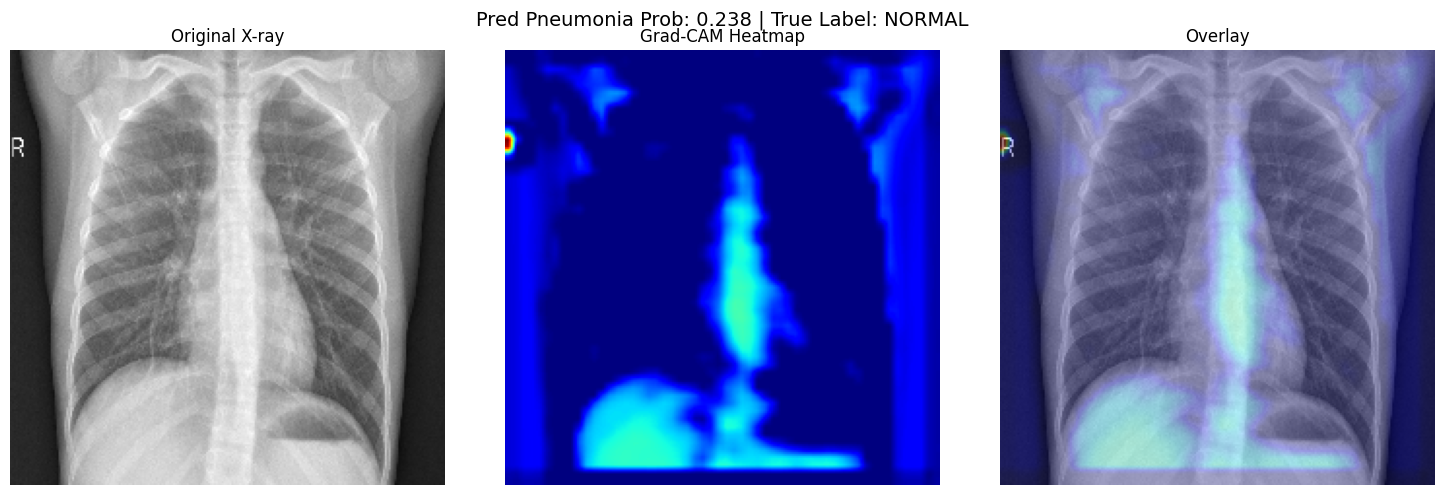

In [ ]:
get_gradcam(1, 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


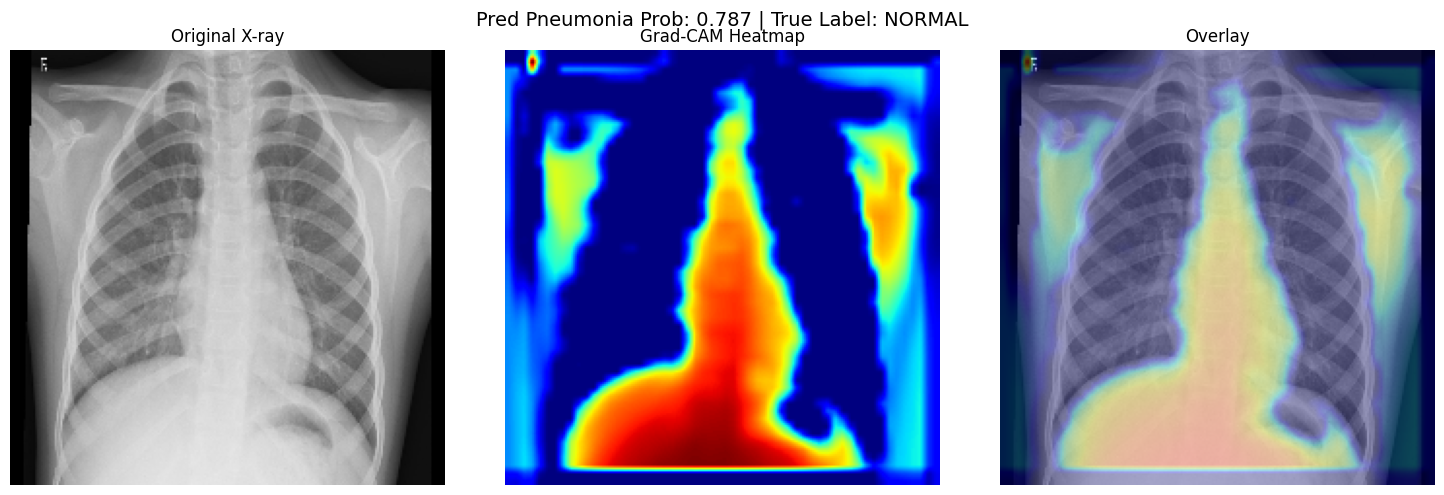

In [ ]:
get_gradcam(6,1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


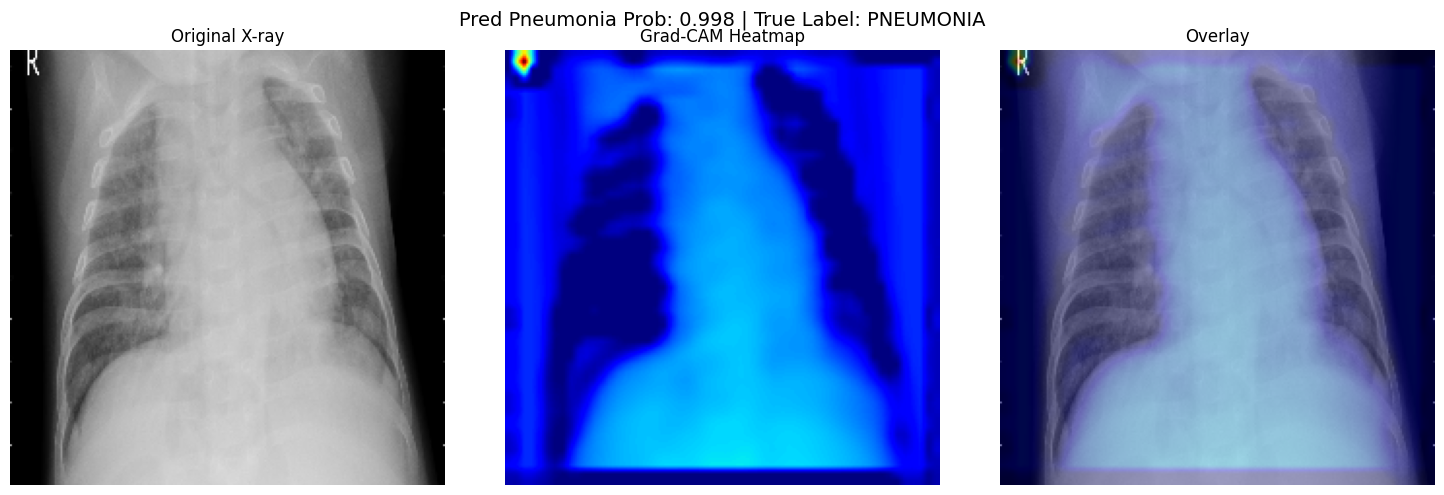

In [ ]:
get_gradcam(6,10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


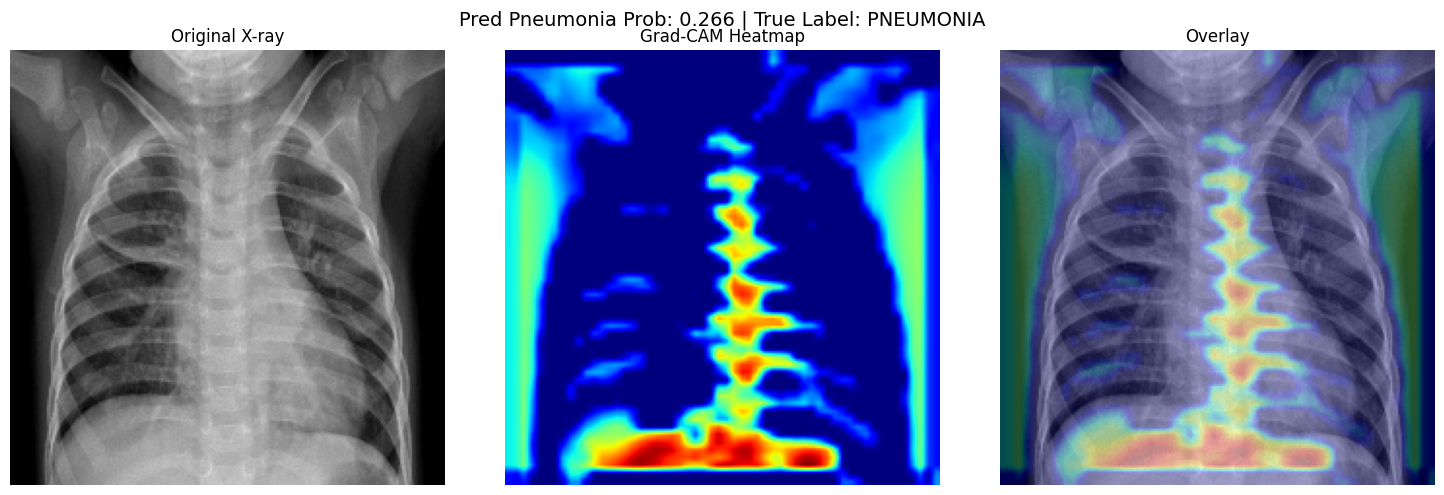

In [ ]:
get_gradcam(13,10)